<a href="https://colab.research.google.com/github/allanjfarias/PISI3/blob/main/notebooks/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação Random Forest

Import de bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score
import shap

e:\Faculdade\PISI3\projetodb\PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load do DF

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_7clusters.csv")

Random Forest

In [3]:
# Carregar os dados (substitua 'df' pelo seu DataFrame real)
new_df = df.copy()

# Separar features (X) e target (y)
X = new_df.drop(columns=['cluster'])  # Features
y = new_df['cluster']                # Target

In [4]:
# Dividir dados em treino e teste (30% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Definir o modelo com hyperparâmetros de regularização
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,               # Limita a profundidade das árvores
    min_samples_split=10,       # Evita divisões em nós com poucas amostras
    min_samples_leaf=2,         # Garante folhas com mais amostras
    max_features='sqrt',        # Usa sqrt(n_features) em cada divisão
    class_weight='balanced',    # Balanceia classes desiguais
    random_state=42
)

# Treinar o modelo
model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=150, random_state=42)

# Avaliação teste

In [5]:
# Previsões no conjunto de treino
y_teste_pred = model.predict(X_test)

Matriz de Confusão para o conjunto de teste:
[[4976  120   90    0   88    1  191]
 [  56 4560   35   65   36    1   93]
 [  14    3 1708    4    7    4   10]
 [   0   18    5 1891   25    1    0]
 [  30    9   17   23 2814    0    9]
 [   0    0    1    0    0  337    0]
 [ 352  217   28    0   75    5 6484]]


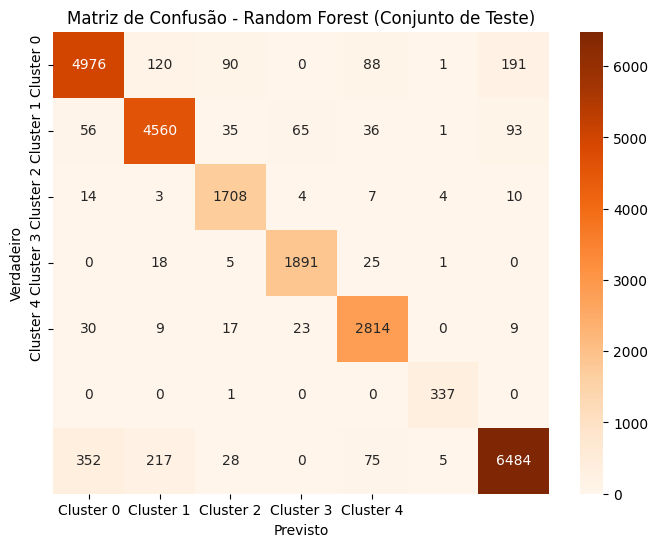

In [6]:
conf_matrix_teste= confusion_matrix(y_test, y_teste_pred)
print("Matriz de Confusão para o conjunto de teste:")
print(conf_matrix_teste)

# Criar os rótulos para os clusters
cluster_labels = [f'Cluster {i}' for i in range(5)]  # Se os clusters forem 0 a 4

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_teste, annot=True, fmt='d', cmap='Oranges',
            xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest (Conjunto de Teste)')
plt.show()



In [7]:
# Relatório de classificação para o conjunto de teste
print("\nMétricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_teste_pred, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']))


Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

   Cluster 0       0.92      0.91      0.91      5466
   Cluster 1       0.93      0.94      0.93      4846
   Cluster 2       0.91      0.98      0.94      1750
   Cluster 3       0.95      0.97      0.96      1940
   Cluster 4       0.92      0.97      0.95      2902
   Cluster 5       0.97      1.00      0.98       338
   Cluster 6       0.96      0.91      0.93      7161

    accuracy                           0.93     24403
   macro avg       0.94      0.95      0.94     24403
weighted avg       0.93      0.93      0.93     24403



# Avaliação do conjunto de treino

In [8]:
# Previsões no conjunto de treino
y_train_pred = model.predict(X_train)


Matriz de Confusão para o conjunto de treino:
[[11802   228   171     0   176     4   385]
 [  119 10671    48    88    71     1   176]
 [   36     4  3968     1     8     1    10]
 [    1    24     0  4575    11     1     0]
 [   59     6    18    14  6601     0    23]
 [    0     0     0     0     0   690     0]
 [  772   419    83     0   170    10 15495]]


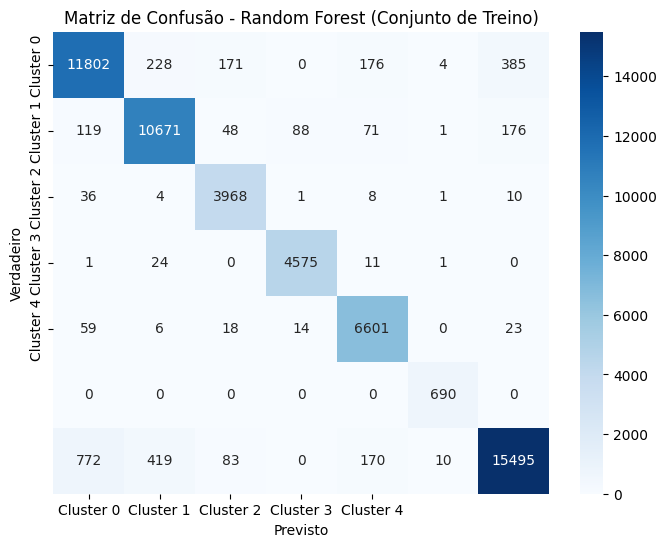

In [9]:

# Matriz de Confusão para o conjunto de treino
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("Matriz de Confusão para o conjunto de treino:")
print(conf_matrix_train)

# Criar os rótulos para os clusters
cluster_labels = [f'Cluster {i}' for i in range(5)]  # Se os clusters forem 0 a 4

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest (Conjunto de Treino)')
plt.show()



In [10]:
# Relatório de classificação para o conjunto de treino
print("\nMétricas de Classificação para o conjunto de treino:")
print(classification_report(y_train, y_train_pred, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']))


Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

   Cluster 0       0.92      0.92      0.92     12766
   Cluster 1       0.94      0.95      0.95     11174
   Cluster 2       0.93      0.99      0.95      4028
   Cluster 3       0.98      0.99      0.98      4612
   Cluster 4       0.94      0.98      0.96      6721
   Cluster 5       0.98      1.00      0.99       690
   Cluster 6       0.96      0.91      0.94     16949

    accuracy                           0.94     56940
   macro avg       0.95      0.96      0.96     56940
weighted avg       0.95      0.94      0.94     56940



In [12]:
# Gerar valores SHAP para o modelo Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Gráfico summary plot para a classe 1 (Popular)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)

KeyboardInterrupt: 

# Cross Validation

In [11]:
# Cross-validation para avaliar overfitting no modelo Random Forest
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

# Calcular acurácia no treino e teste
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print("Acurácia no treino:", train_acc)
print("Acurácia no teste:", test_acc)

Acurácias de cross-validation: [0.92773094 0.93308746 0.93097998 0.93282403 0.92878469]
Média da acurácia de cross-validation: 0.9306814190375835
Acurácia no treino: 0.9448893572181244
Acurácia no teste: 0.9330819981149858
